In [78]:
!pip install gradio scikit-learn

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import gradio as gr

In [80]:
from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart (2).csv


In [81]:
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [82]:
df = pd.read_csv('heart.csv')
df.shape

(1025, 14)

In [83]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [84]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [85]:
X = df.drop('target', axis=1)
y = df['target']

In [86]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [87]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [88]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu',),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [89]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [90]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.7317 - loss: 0.5876 - val_accuracy: 0.7561 - val_loss: 0.5382
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8293 - loss: 0.4359 - val_accuracy: 0.7866 - val_loss: 0.4613
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8659 - loss: 0.3557 - val_accuracy: 0.8049 - val_loss: 0.4283
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8811 - loss: 0.3138 - val_accuracy: 0.8171 - val_loss: 0.4158
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8902 - loss: 0.2897 - val_accuracy: 0.8232 - val_loss: 0.4102
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8963 - loss: 0.2751 - val_accuracy: 0.8293 - val_loss: 0.4093
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9070 - loss: 0.2609 - val_accuracy: 0.8415 - val_loss: 0.4021
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9131 - loss: 0.2497 - val_accuracy: 0.

In [91]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Akurasi Model =",accuracy)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9561 - loss: 0.2958 
Akurasi Model = 0.9560975432395935


In [92]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

cm = confusion_matrix(y_test, y_pred)
print(cm)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
[[100   2]
 [  7  96]]


In [93]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.98      0.96       102
           1       0.98      0.93      0.96       103

    accuracy                           0.96       205
   macro avg       0.96      0.96      0.96       205
weighted avg       0.96      0.96      0.96       205



/tmp/ipykernel_1802/3401114040.py:9: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend('Train', 'Validation')


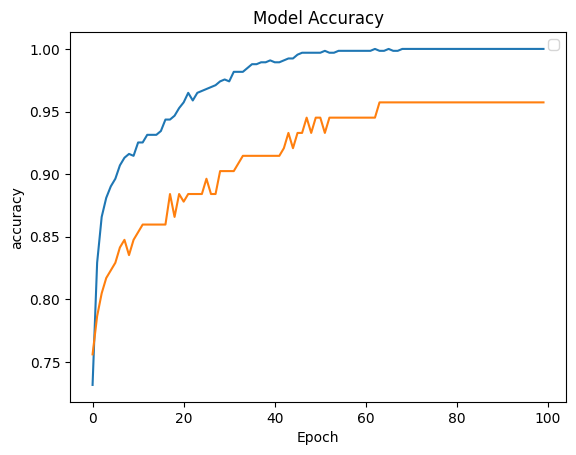

In [94]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('accuracy')
plt.legend('Train', 'Validation')

plt.show()

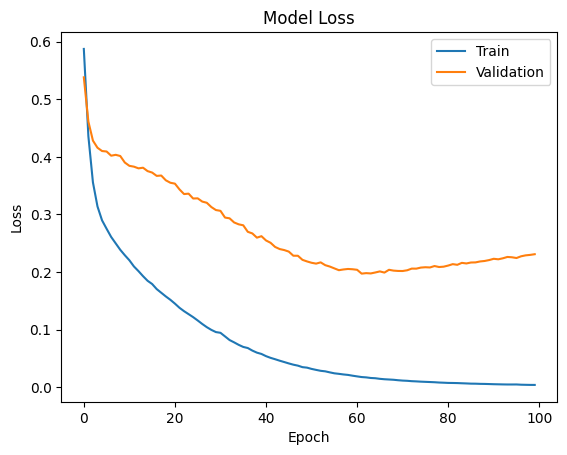

In [95]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.show()

In [96]:
model.save('model_jst.h5')

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


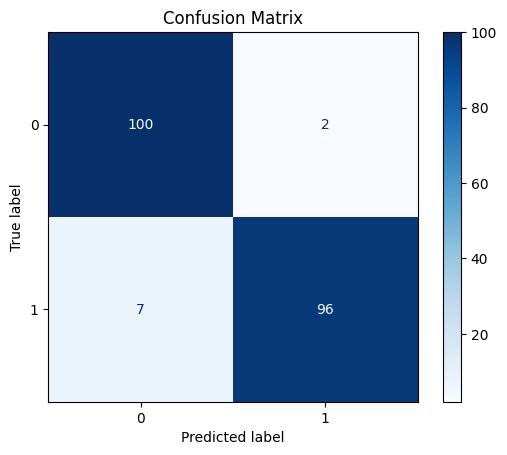

In [97]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

In [98]:
!ls

'heart (1).csv'   heart.csv	 sample_data
'heart (2).csv'   model_jst.h5	 scaler.save


In [99]:
from google.colab import files
files.download('model_jst.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [100]:
import gradio as gr

In [101]:
import joblib
joblib.dump(scaler, 'scaler.save')

['scaler.save']

In [102]:
from google.colab import files
files.download('scaler.save')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [106]:
import numpy as np

def prediksi(age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal):
  data = np.array([[age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal]])
  data = scaler.transform(data)
  hasil  = model.predict(data)[0][0]
  if hasil > 0.5:
    return """
    🤦‍♂️Berpotensi Penyakit jantung

    Model AI kami kelompok 4 adalah mendeteksi penyakit jantung, nah pada kali ini Kemungkinan risiko penyakit jantung berdasarkan data yang di masukan,
    Penyebabnya dapat di pengaruhi beberapa faktor seperti tekanan darah tinggi, kadar kolestrol tinggi, kurangnya aktivitas fisik, serta gaya hidup yang sehat.

    Saran Dari Kelomok 4 kami :
    • Konsultasi Segera dengan dokter untuk pemeriksaan lebih lanjut.
    • Kurangi makanan tinggi lemak dan kolestrol.
    • Rutin Olahraga Jauhi Kebiasaan Merokok.
    • Jaga Pola Tidur Dan Kelolas Stres Anda Dengan baik

    Dan Ingat Ini Adalah Hasil AI Dari Kelompok 4 KAMI😁🙌"""
  else:
    return """✅Tidak Berpotensi Penyakit jantung

    Wah Anda Sehat Wal-Afiat Pertahnkan Dengan Cara:

    • Pertahankan Pola Makan Yang sehat.
    • Tetap Jaga Kerutinan Dalam Olahraga.
    • Terus Usahakan Hindari Rokok Mau itu Langsung Merokok Ataupun Sedang Dekat Seorang Perokok.
    Oke Sealamt Berbahagia Dan Sampai Jumpa 'Wassalam'"""

In [105]:
import gradio as gr

demo = gr.Interface(
    fn=prediksi,
    inputs=[
        gr.Number(label="Umur"),
        gr.Number(label="Jenis Kelamin"),
        gr.Number(label="Tipe Dada"),
        gr.Number(label="Tekanan Darah"),
        gr.Number(label="Kolesterol"),
        gr.Number(label="Gula Darah"),
        gr.Number(label="Hasil Rekaman EKG"),
        gr.Number(label="Detak Jantung Maksimum"),
        gr.Number(label="Angina"),
        gr.Number(label="Oldpeak"),
        gr.Number(label="Slope"),
        gr.Number(label="Nilai CA"),
        gr.Number(label="Nilai Thal")
    ],
    outputs="text",
    title="MemPrediksi Penyakit Jantung Menggunakan JST",
    description="""Masukan Data Pasien Kemudian Pencet Summit.AI akan memPrediksi apakah pasien berpotensi terkena penyakit Jantung atau Tidak"""
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://be96f9019ff17367ce.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
